In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import norm

sns.set_theme(style="darkgrid")

with open("portfolio_data.pkl", "rb") as f:
    data = pickle.load(f)

log_returns       = data["log_returns"]
portfolio_returns = data["portfolio_returns"]
cov_matrix        = data["cov_matrix"]        
tickers           = data["tickers"]
weights_ew        = data["weights"]            
conf_levels       = data["conf_levels"]

N = len(tickers)

mu_ann = log_returns.mean() * 252
cov_ann = cov_matrix   # already annualised

print("Loaded successfully.")
print(f"\nAssets: {tickers}")
print(f"\nAnnualised mean returns:")
for t, m in zip(tickers, mu_ann):
    print(f"  {t:6s}: {m*100:.2f}%")

Loaded successfully.

Assets: ['SPY', 'QQQ', 'EFA', 'GLD', 'TLT', 'LQD', 'XOM', 'VNQ']

Annualised mean returns:
  SPY   : 12.29%
  QQQ   : 16.93%
  EFA   : 5.12%
  GLD   : 7.48%
  TLT   : -1.20%
  LQD   : 2.23%
  XOM   : 5.67%
  VNQ   : 4.71%


In [2]:
import os

_cwd = os.getcwd()
_proj_root = _cwd if os.path.exists(os.path.join(_cwd, "README.md")) else os.path.dirname(_cwd)
RESULTS = os.path.join(_proj_root, "results", "phase_8_optimizer")
os.makedirs(RESULTS, exist_ok=True)
print(f"Results folder: {RESULTS}")

Results folder: c:\Users\kshit\VaR CVaR\results\phase_8_optimizer


In [ ]:
def portfolio_metrics(weights, mu, cov):
    """Returns annualised return, vol, and Sharpe (rf=0) for a weight vector."""
    ret = float(np.dot(weights, mu))
    vol = float(np.sqrt(weights @ cov.values @ weights))
    sharpe = ret / vol
    return ret, vol, sharpe

# Constraints and bounds used in every optimisation
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]  
bounds = [(0, 1)] * N                                              # long only
w0 = np.array([1 / N] * N)                                        # starting guess

# Verify equal-weight baseline
ew_ret, ew_vol, ew_sharpe = portfolio_metrics(weights_ew, mu_ann, cov_ann)
print(f"Equal-Weight baseline:")
print(f"  Ann. Return : {ew_ret*100:.2f}%")
print(f"  Ann. Vol    : {ew_vol*100:.2f}%")
print(f"  Sharpe      : {ew_sharpe:.3f}")

Equal-Weight baseline:
  Ann. Return : 6.66%
  Ann. Vol    : 11.71%
  Sharpe      : 0.568


In [ ]:
res_mv = minimize(
    fun=lambda w: w @ cov_ann.values @ w,   # minimise portfolio variance
    x0=w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

weights_mv = res_mv.x
mv_ret, mv_vol, mv_sharpe = portfolio_metrics(weights_mv, mu_ann, cov_ann)

print(f"Minimum Variance Portfolio:")
print(f"  Ann. Return : {mv_ret*100:.2f}%")
print(f"  Ann. Vol    : {mv_vol*100:.2f}%")
print(f"  Sharpe      : {mv_sharpe:.3f}")
print(f"\n  Weights:")
for t, w in zip(tickers, weights_mv):
    bar = "█" * int(w * 40)
    print(f"  {t:6s}: {w*100:5.1f}%  {bar}")

Minimum Variance Portfolio:
  Ann. Return : 3.92%
  Ann. Vol    : 7.99%
  Sharpe      : 0.491

  Weights:
  SPY   :   6.7%  ██
  QQQ   :   0.0%  
  EFA   :   0.0%  
  GLD   :  16.5%  ██████
  TLT   :   0.0%  
  LQD   :  72.5%  █████████████████████████████
  XOM   :   4.3%  █
  VNQ   :   0.0%  


In [ ]:
def neg_sharpe(w):
    ret = np.dot(w, mu_ann)
    vol = np.sqrt(w @ cov_ann.values @ w)
    return -ret / vol   # minimise negative Sharpe = maximise Sharpe

res_ms = minimize(
    fun=neg_sharpe,
    x0=w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

weights_ms = res_ms.x
ms_ret, ms_vol, ms_sharpe = portfolio_metrics(weights_ms, mu_ann, cov_ann)

print(f"Maximum Sharpe Portfolio:")
print(f"  Ann. Return : {ms_ret*100:.2f}%")
print(f"  Ann. Vol    : {ms_vol*100:.2f}%")
print(f"  Sharpe      : {ms_sharpe:.3f}")
print(f"\n  Weights:")
for t, w in zip(tickers, weights_ms):
    bar = "█" * int(w * 40)
    print(f"  {t:6s}: {w*100:5.1f}%  {bar}")

Maximum Sharpe Portfolio:
  Ann. Return : 12.17%
  Ann. Vol    : 13.32%
  Sharpe      : 0.914

  Weights:
  SPY   :   0.0%  
  QQQ   :  49.7%  ███████████████████
  EFA   :   0.0%  
  GLD   :  50.3%  ████████████████████
  TLT   :   0.0%  
  LQD   :   0.0%  
  XOM   :   0.0%  
  VNQ   :   0.0%  


In [6]:
target_returns = np.linspace(mv_ret, mu_ann.max(), 60)

frontier_vols    = []
frontier_rets    = []
frontier_weights = []

for target in target_returns:
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w, t=target: np.dot(w, mu_ann) - t},
    ]
    res = minimize(
        fun=lambda w: w @ cov_ann.values @ w,
        x0=w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
    )
    if res.success:
        vol = np.sqrt(res.fun)
        frontier_vols.append(vol)
        frontier_rets.append(target)
        frontier_weights.append(res.x)

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

print(f"Frontier computed: {len(frontier_vols)} points")
print(f"  Vol range  : {frontier_vols.min()*100:.2f}% → {frontier_vols.max()*100:.2f}%")
print(f"  Ret range  : {frontier_rets.min()*100:.2f}% → {frontier_rets.max()*100:.2f}%")

Frontier computed: 60 points
  Vol range  : 7.99% → 21.88%
  Ret range  : 3.92% → 16.93%


## Step 5 — Plot the Efficient Frontier

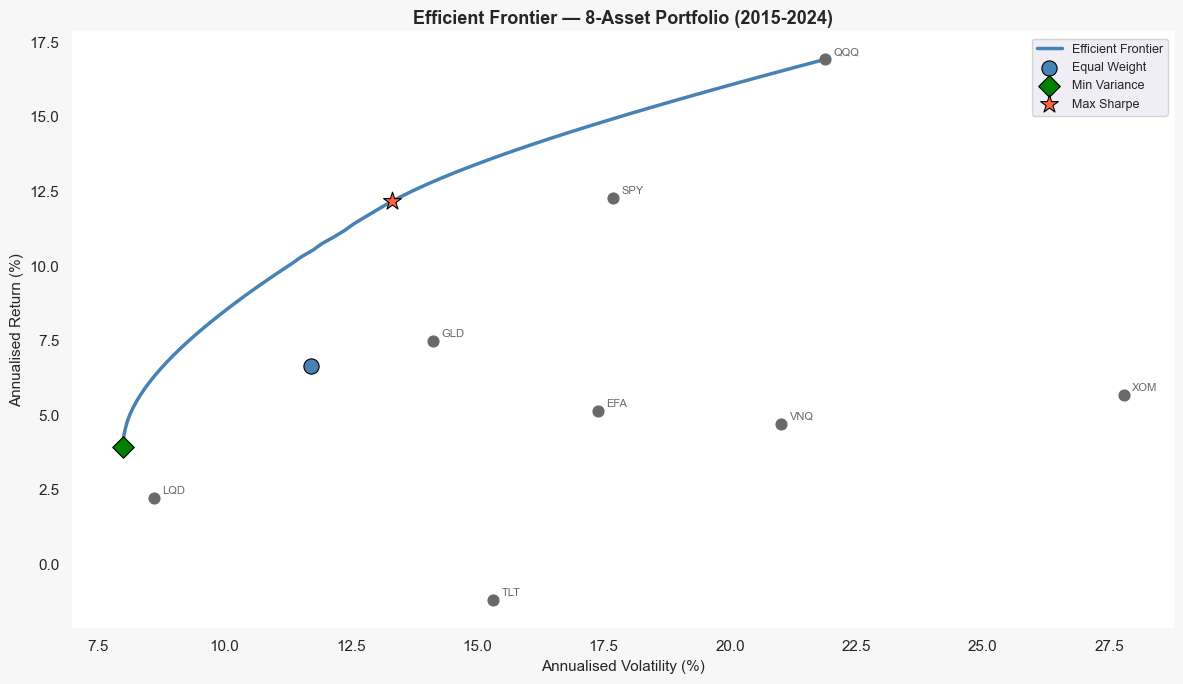

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#f7f7f7")
ax.set_facecolor("#ffffff")

ax.plot(frontier_vols * 100, frontier_rets * 100,
        color="steelblue", linewidth=2.5, label="Efficient Frontier", zorder=3)

for i, ticker in enumerate(tickers):
    v = np.sqrt(cov_ann.values[i, i])
    r = mu_ann.iloc[i]
    ax.scatter(v * 100, r * 100, s=60, color="dimgray", zorder=4)
    ax.annotate(ticker, (v * 100, r * 100),
                textcoords="offset points", xytext=(6, 3), fontsize=8, color="dimgray")

portfolios = [
    ("Equal Weight",    ew_vol,  ew_ret,  "steelblue", "o", 120),
    ("Min Variance",    mv_vol,  mv_ret,  "green",     "D", 120),
    ("Max Sharpe",      ms_vol,  ms_ret,  "tomato",    "*", 180),
]
for label, vol, ret, color, marker, size in portfolios:
    ax.scatter(vol * 100, ret * 100, s=size, color=color,
               marker=marker, zorder=5, label=label, edgecolors="black", linewidth=0.8)

ax.set_xlabel("Annualised Volatility (%)", fontsize=11)
ax.set_ylabel("Annualised Return (%)", fontsize=11)
ax.set_title("Efficient Frontier — 8-Asset Portfolio (2015-2024)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "01_efficient_frontier.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
PV = 1_000_000

def hs_var_cvar(returns_series, confidence):
    r = returns_series.values
    var  = -np.percentile(r, (1 - confidence) * 100)
    tail = r[r < -var]
    cvar = -tail.mean()
    return var, cvar

# Compute return series for each optimised portfolio
rets_mv = log_returns.dot(weights_mv)
rets_ms = log_returns.dot(weights_ms)
rets_ew = portfolio_returns   # already computed

rows = []
for name, w, rets in [
    ("Equal Weight",  weights_ew, rets_ew),
    ("Min Variance",  weights_mv, rets_mv),
    ("Max Sharpe",    weights_ms, rets_ms),
]:
    p_ret, p_vol, p_sharpe = portfolio_metrics(w, mu_ann, cov_ann)
    var95,  cvar95  = hs_var_cvar(rets, 0.95)
    var99,  cvar99  = hs_var_cvar(rets, 0.99)
    rows.append({
        "Portfolio":      name,
        "Ann. Return":    f"{p_ret*100:.2f}%",
        "Ann. Vol":       f"{p_vol*100:.2f}%",
        "Sharpe":         f"{p_sharpe:.3f}",
        "95% VaR ($)":    f"${var95*PV:,.0f}",
        "99% VaR ($)":    f"${var99*PV:,.0f}",
        "95% CVaR ($)":   f"${cvar95*PV:,.0f}",
        "99% CVaR ($)":   f"${cvar99*PV:,.0f}",
    })

summary = pd.DataFrame(rows).set_index("Portfolio")
print("── Portfolio Comparison: Construction vs Risk ───────────────────")
print(summary.to_string())

── Portfolio Comparison: Construction vs Risk ───────────────────
             Ann. Return Ann. Vol Sharpe 95% VaR ($) 99% VaR ($) 95% CVaR ($) 99% CVaR ($)
Portfolio                                                                                 
Equal Weight       6.66%   11.71%  0.568     $10,610     $18,887      $17,442      $31,791
Min Variance       3.92%    7.99%  0.491      $7,114     $12,151      $11,284      $20,248
Max Sharpe        12.17%   13.32%  0.914     $13,425     $22,197      $19,761      $31,051


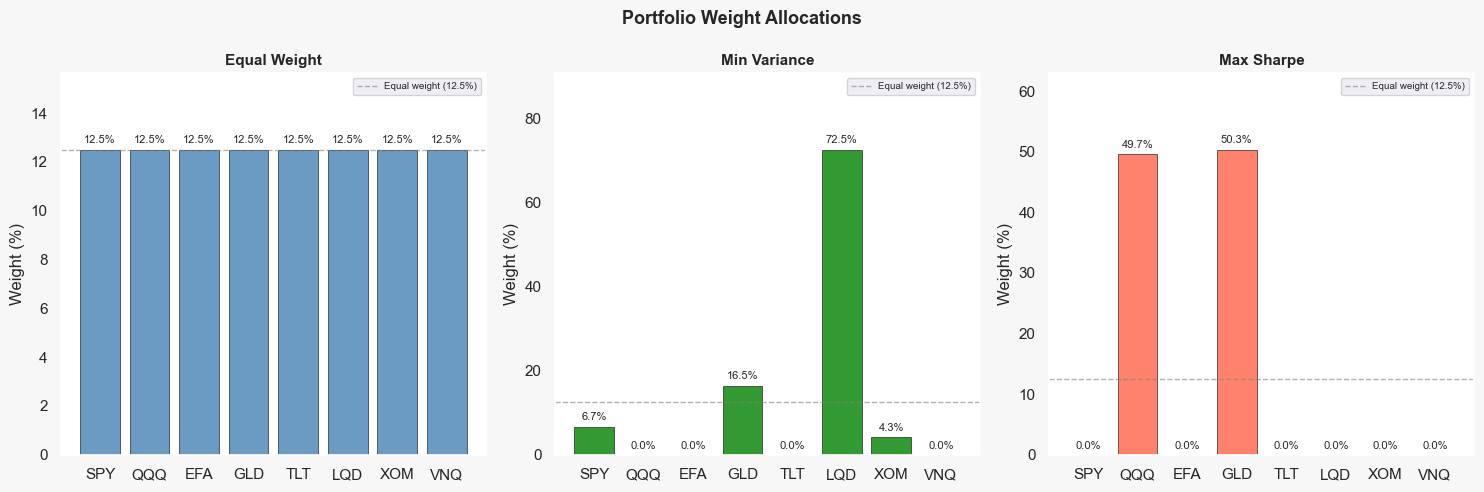

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#f7f7f7")

configs = [
    ("Equal Weight",  weights_ew, "steelblue"),
    ("Min Variance",  weights_mv, "green"),
    ("Max Sharpe",    weights_ms, "tomato"),
]

for ax, (title, w, color) in zip(axes, configs):
    bars = ax.bar(tickers, w * 100, color=color, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Weight (%)")
    ax.set_ylim(0, max(w * 100) * 1.25)
    ax.axhline(12.5, color="grey", linewidth=1, linestyle="--", alpha=0.6,
               label="Equal weight (12.5%)")
    ax.legend(fontsize=7)
    ax.set_facecolor("#ffffff")

plt.suptitle("Portfolio Weight Allocations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "02_portfolio_weights.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
opt_results = {
    "weights_mv":       weights_mv,
    "weights_ms":       weights_ms,
    "frontier_vols":    frontier_vols,
    "frontier_rets":    frontier_rets,
    "frontier_weights": frontier_weights,
    "rets_mv":          rets_mv,
    "rets_ms":          rets_ms,
}

data.update(opt_results)

with open("portfolio_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("portfolio_data.pkl updated with Phase 8 optimisation results.")
print(f"\nSummary:")
print(f"  Min Variance  — Vol: {mv_vol*100:.2f}%  Return: {mv_ret*100:.2f}%  Sharpe: {mv_sharpe:.3f}")
print(f"  Max Sharpe    — Vol: {ms_vol*100:.2f}%  Return: {ms_ret*100:.2f}%  Sharpe: {ms_sharpe:.3f}")
print(f"  Equal Weight  — Vol: {ew_vol*100:.2f}%  Return: {ew_ret*100:.2f}%  Sharpe: {ew_sharpe:.3f}")

portfolio_data.pkl updated with Phase 8 optimisation results.

Summary:
  Min Variance  — Vol: 7.99%  Return: 3.92%  Sharpe: 0.491
  Max Sharpe    — Vol: 13.32%  Return: 12.17%  Sharpe: 0.914
  Equal Weight  — Vol: 11.71%  Return: 6.66%  Sharpe: 0.568
